# Exercise 4 - Chemostat: Yeast Biomass Production

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


**Question a)**
In a chemostat at steady state, the specific growth rate $\mu$ equals the dilution rate $D$:

$$D = \mu = \mu_{\max} \frac{S}{K_s + S}$$

where:
- $\mu_{\max}$ is the maximum specific growth rate (h⁻¹)
- $K_s$ is the saturation (Monod) constant (g/L)
- $S$ is the steady-state substrate concentration (g/L)

This equation is true because at steady state, cell growth exactly compensates for dilution losses.

Taking the reciprocal of the Monod equation:

$$\frac{1}{D} = \frac{K_s}{\mu_{\max}} \cdot \frac{1}{S} + \frac{1}{\mu_{\max}}$$

Plotting $1/D$ versus $1/S$ yields a straight line with:
- slope $= K_s / \mu_{\max}$
- y-intercept $= 1 / \mu_{\max}$
- x-intercept $= -1 / K_s$

The highest dilution rate ($D = 0.84$ h⁻¹) is excluded from the fit because at this operating point, cell concentration drops sharply and residual substrate jumps, indicating washout. This means that cells can no longer grow fast enough to keep up with dilution, so they are being removed from the reactor faster than they reproduce. Including these points would therefore violate the steady-state assumption.

  Monod parameter estimation (part a)
  Slope     (Ks / µmax) = 0.2386  h·g/L
  Intercept (1 / µmax)  = 0.4351  h
  µmax                  = 2.2982  h⁻¹
  Ks                    = 0.5482  g/L


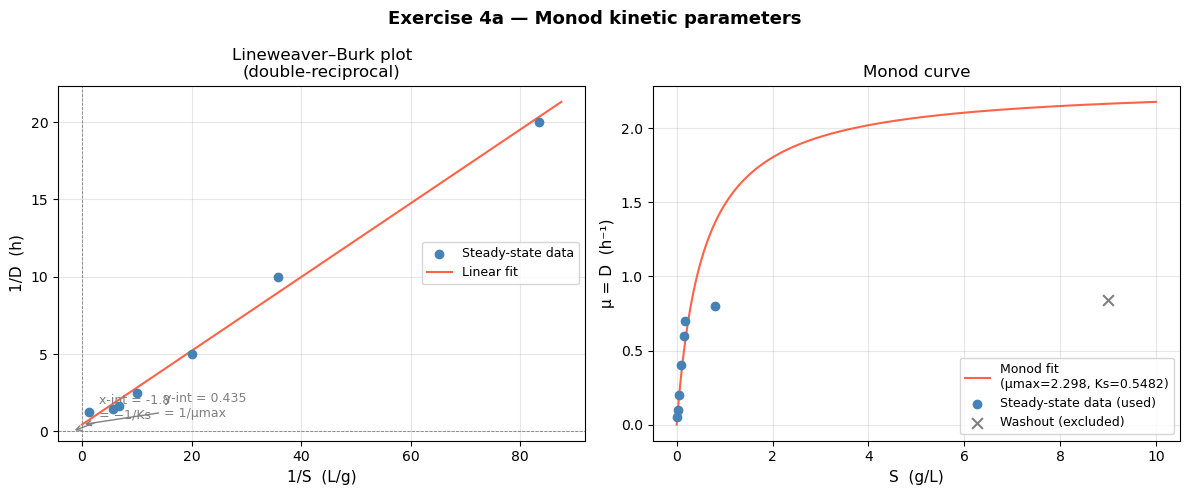

In [14]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])  
X = np.array([3.2,  3.7,  4.0,  4.4,  4.75, 4.9,  4.5,  0.5])   
S = np.array([0.012,0.028,0.050,0.100,0.150,0.176,0.800,9.000])  
S0 = 10.0  

mask   = D <= 0.80
D_fit  = D[mask]
S_fit  = S[mask]

inv_D = 1.0 / D_fit
inv_S = 1.0 / S_fit

slope, intercept = np.polyfit(inv_S, inv_D, 1)

mu_max = 1.0 / intercept       
Ks     = slope * mu_max          

print("=" * 45)
print("  Monod parameter estimation (part a)")
print("=" * 45)
print(f"  Slope     (Ks / µmax) = {slope:.4f}  h·g/L")
print(f"  Intercept (1 / µmax)  = {intercept:.4f}  h")
print(f"  µmax                  = {mu_max:.4f}  h⁻¹")
print(f"  Ks                    = {Ks:.4f}  g/L")
print("=" * 45)

inv_S_line = np.linspace(0, max(inv_S) * 1.05, 300)
inv_D_line = slope * inv_S_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(inv_S, inv_D, color="steelblue", zorder=5, label="Steady-state data")
ax1.plot(inv_S_line, inv_D_line, color="tomato", label="Linear fit")

ax1.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax1.axvline(0, color="grey", linewidth=0.6, linestyle="--")

ax1.annotate(f"y-int = {intercept:.3f}\n= 1/µmax",
             xy=(0, intercept), xytext=(15, intercept + 0.5),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")
x_int = -intercept / slope          # x-intercept = −1/Ks
ax1.annotate(f"x-int = {x_int:.1f}\n= −1/Ks",
             xy=(x_int, 0), xytext=(x_int + 5, 0.8),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")

ax1.set_xlabel("1/S  (L/g)", fontsize=11)
ax1.set_ylabel("1/D  (h)", fontsize=11)
ax1.set_title("Lineweaver–Burk plot\n(double-reciprocal)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
S_range = np.linspace(0, S0, 500)
mu_monod = mu_max * S_range / (Ks + S_range)

ax2.plot(S_range, mu_monod, color="tomato", label=f"Monod fit\n(µmax={mu_max:.3f}, Ks={Ks:.4f})")
ax2.scatter(S_fit, D_fit, color="steelblue", zorder=5, label="Steady-state data (used)")
ax2.scatter(S[~mask], D[~mask], color="grey", marker="x", zorder=5, s=60, label="Washout (excluded)")

ax2.set_xlabel("S  (g/L)", fontsize=11)
ax2.set_ylabel("µ = D  (h⁻¹)", fontsize=11)
ax2.set_title("Monod curve", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Exercise 4a — Monod kinetic parameters", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

| Parameter | Value | Units |
|-----------|-------|-------|
| $\mu_{\max}$ | 2.2982 | h⁻¹ |
| $K_s$ | 0.5482 | g/L |

The Lineweaver–Burk linearisation yields $\mu_{\max} = 2.2982\ \text{h}^{-1}$ and $K_s = 0.5482\ \text{g/L}$. The $\mu_{\max}$ value exceeds typical aerobic literature values for yeast growth, and $K_s$ is higher than commonly reported. This is likely attributable to the double-reciprocal transformation: taking $1/S$ compresses the high-substrate points and stretches the low-substrate points, giving disproportionate weight to the least reliable measurements (low $S$, high $1/S$). The fit is therefore dominated by the point at $S = 0.012$ g/L, which pulls the line and inflates both parameters.
 
To obtain more reliable estimates, the Monod equation is fitted directly to the $(S, D)$ data using non-linear least squares regression.
Instead of transforming the data, `scipy.optimize.curve_fit` minimises the sum of squared residuals directly in the original data space:
 
$$\min_{\mu_{\max},\, K_s} \sum_i \left( D_i - \mu_{\max} \frac{S_i}{K_s + S_i} \right)^2$$
 
This avoids any distortion introduced by the double-reciprocal transformation and gives equal statistical weight to all data points. 
 

Parameter          Lineweaver-Burk         Non-linear
-------------------------------------------------------
µmax (h⁻¹)                  2.2982             0.9975
Ks (g/L)                    0.5482             0.1288
R²                          0.3520             0.9304

Non-linear 1σ uncertainties:  µmax ± 0.1332 h⁻¹  |  Ks ± 0.0433 g/L


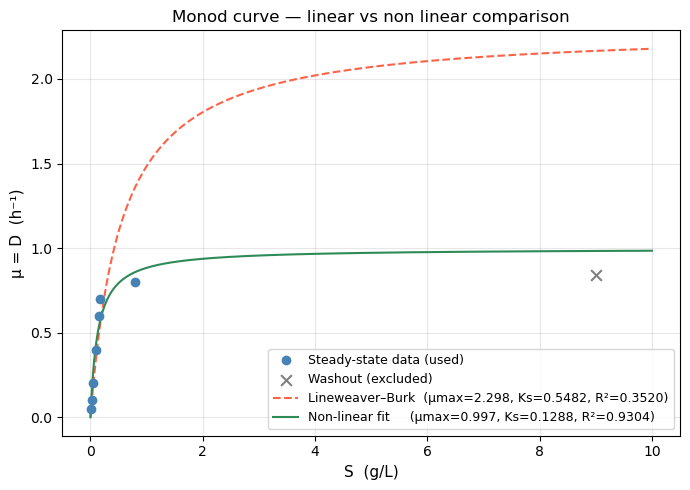

In [16]:
from scipy.optimize import curve_fit

def monod(S, mu_max, Ks):
    return mu_max * S / (Ks + S)

popt, pcov   = curve_fit(monod, S_fit, D_fit, p0=[1.0, 0.1], bounds=(0, np.inf))
mu_max_nl, Ks_nl = popt
perr             = np.sqrt(np.diag(pcov))   # 1-sigma uncertainties

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

R2_lb = r_squared(D_fit, monod(S_fit, mu_max, Ks))       # mu_max, Ks from LB cell
R2_nl = r_squared(D_fit, monod(S_fit, mu_max_nl, Ks_nl))


print("=" * 55)
print(f"{'Parameter':<15} {'Lineweaver-Burk':>18} {'Non-linear':>18}")
print("-" * 55)
print(f"{'µmax (h⁻¹)':<15} {mu_max:>18.4f} {mu_max_nl:>18.4f}")
print(f"{'Ks (g/L)':<15} {Ks:>18.4f} {Ks_nl:>18.4f}")
print(f"{'R²':<15} {R2_lb:>18.4f} {R2_nl:>18.4f}")
print("=" * 55)
print(f"\nNon-linear 1σ uncertainties:  µmax ± {perr[0]:.4f} h⁻¹  |  Ks ± {perr[1]:.4f} g/L")


S_range = np.linspace(0, S0, 500)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(S_fit,    D_fit,    color="steelblue", zorder=5, label="Steady-state data (used)")
ax.scatter(S[~mask], D[~mask], color="grey", marker="x", s=60, zorder=5, label="Washout (excluded)")
ax.plot(S_range, monod(S_range, mu_max, Ks), color="tomato", linestyle="--",
        label=f"Lineweaver–Burk  (µmax={mu_max:.3f}, Ks={Ks:.4f}, R²={R2_lb:.4f})")
ax.plot(S_range, monod(S_range, mu_max_nl, Ks_nl), color="seagreen",
        label=f"Non-linear fit     (µmax={mu_max_nl:.3f}, Ks={Ks_nl:.4f}, R²={R2_nl:.4f})")

ax.set_xlabel("S  (g/L)", fontsize=11)
ax.set_ylabel("µ = D  (h⁻¹)", fontsize=11)
ax.set_title("Monod curve — linear vs non linear comparison", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We get the following results now:

| Parameter | Lineweaver–Burk | Non-linear regression |
|-----------|:--------------:|:--------------------:|
| $\mu_{\max}$ (h⁻¹) | 2.2982 | 0.9975 |
| $K_s$ (g/L) | 0.5482 | 0.1288 |
| $R^2$ | 0.3520 | 0.9304 |

The non-linear regression yields a higher $R^2$ value and parameters that are more consistent with literature values for aerobic yeast growth, confirming that the Lineweaver–Burk overestimation was an result of the double-reciprocal transformation rather than a true biological feature of the data.

The $1\sigma$ uncertainties from the covariance matrix of `curve_fit` further quantify the reliability of the non-linear estimates. However, for consistency with the methodology presented in lecture 2 of the course, the Lineweaver–Burk estimates were used in the subsequent analysis.

**Question b)**

At steady state in a chemostat, the substrate consumed goes towards two things: producing new biomass and covering the maintenance energy requirements of existing cells:
 
$$D(S_{in} - S) = \frac{\mu \cdot X}{Y_{X/S}} + m \cdot X$$
 
where:
- $Y_{X/S}$ is the true biomass yield on substrate (g biomass / g substrate)
- $m$ is the maintenance energy coefficient (g substrate / g biomass / h)
- $S_{in} - S$ is the substrate consumed (g/L)

This is also known as the Herbirt Pirt equation.
 
Since $D = \mu$ at steady state, dividing both sides by $X$ gives a linear form:
 
$$\frac{D(S_{in} - S)}{X} = \frac{1}{Y_{X/S}} \cdot D + m$$
 
Plotting $\frac{D(S_{in} - S)}{X}$ against $D$ yields a straight line where:
- slope $= 1/Y_{X/S}$
- y-intercept $= m$
 
The parameters are estimated using `numpy.polyfit` on the steady-state data points (washout point at $D = 0.84$ h⁻¹ excluded).
 

slope = 1.9285
intercept = 0.0872
Yxs = 0.5185 gX/gS
m = 0.0872 gS/(gX·h)


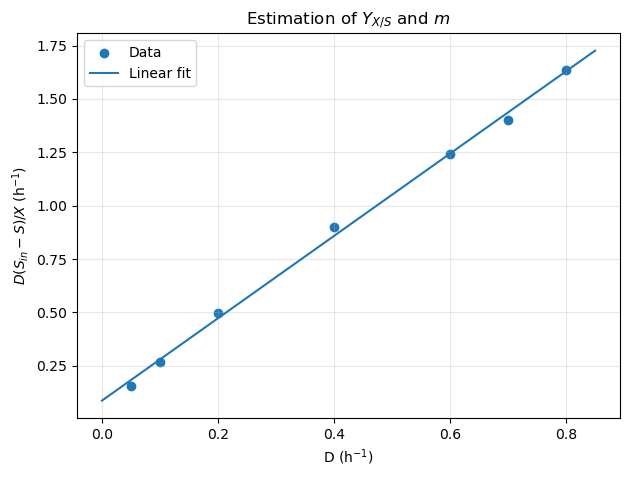

In [ ]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])
X = np.array([3.2, 3.7, 4.0, 4.4, 4.75, 4.9, 4.5, 0.5])
S = np.array([0.012, 0.028, 0.050, 0.100, 0.150, 0.176, 0.800, 9.000])

S_in = 10.0

mask = D <= 0.80
D_fit = D[mask]
X_fit = X[mask]
S_fit = S[mask]

y = D_fit * (S_in - S_fit) / X_fit

slope, intercept = np.polyfit(D_fit, y, 1)

Yxs = 1 / slope
m = intercept

print(f"slope = {slope:.4f}")
print(f"intercept = {intercept:.4f}")
print(f"Yxs = {Yxs:.4f} gX/gS")
print(f"m = {m:.4f} gS/(gX·h)")

# plot
D_line = np.linspace(0, 0.85, 200)
y_line = slope * D_line + intercept

plt.figure(figsize=(7,5))
plt.scatter(D_fit, y, label="Data")
plt.plot(D_line, y_line, label="Linear fit")
plt.xlabel("D (h$^{-1}$)")
plt.ylabel(r"$D(S_{in}-S)/X$ (h$^{-1}$)")
plt.title("Estimation of $Y_{X/S}$ and $m$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

| Parameter | Value | Units |
|-----------|-------|-------|
| $Y_{X/S}$ | 0.5185 | g biomass / g substrate |
| $m$ | 0.0872 | g substrate / g biomass / h |
 
The estimated yield coefficient $Y_{X/S} = 0.5185\ \mathrm{g_X/g_S}$ indicates that approximately 0.52 g of biomass are produced per gram of substrate consumed. This value is lower than 1, which is expected, as part of the substrate is not converted into biomass but is instead used for energy production and cellular functions. Next, the maintenance coefficient $m = 0.0872\ \mathrm{g_S\,g_X^{-1}\,h^{-1}}$ represents the amount of substrate consumed per unit biomass and time for non-growth-related processes. These include cellular maintenance activities such as ion transport, macromolecule turnover, and metabolic regulation. The positive value of $m$ is reflected by the non-zero y-intercept of the linear fit, indicating that even at very low growth rates, substrate is still consumed. This confirms the presence of maintenance metabolism in the system.

Overall, the results are physically consistent. In fact, the yield coefficient is within a reasonable range for microbial systems, and the maintenance term highlights that not all substrate contributes directly to biomass formation, especially at low dilution rates.

**Question c)**

Ignoring maintenance, the steady-state chemostat follows Monod kinetics:

$$
D=\mu=\mu_{\max}\frac{S}{K_s+S}
$$

**Maximum dilution rate**
The maximum dilution rate is reached at washout, when the reactor substrate concentration approaches the feed substrate concentration:

$$
S \to S_{in}
$$

Therefore,

$$
D_{\max}=\mu_{\max}\frac{S_{in}}{K_s+S_{in}}
$$

Using $\mu_{\max}=2.298\ \mathrm{h^{-1}}$, $K_s=0.548\ \mathrm{g\,L^{-1}}$, and $S_{in}=10\ \mathrm{g\,L^{-1}}$:

$$
D_{\max}=2.298\frac{10}{0.548+10}=2.179\ \mathrm{h^{-1}}
$$

**Optimal dilution rate**

The cell productivity is:

$$
P_X=D\cdot X
$$

Ignoring maintenance,

$$
X=Y_{X/S}(S_{in}-S)
$$

so maximizing productivity is equivalent to maximizing:

$$
D(S_{in}-S)
$$

From the Monod relation,

$$
D=\mu_{\max}\frac{S}{K_s+S}
$$

we solve for $S$:

$$
S=\frac{DK_s}{\mu_{\max}-D}
$$

Substituting into the productivity expression and maximizing with respect to $D$ gives:

$$
D_{\mathrm{opt}}=\mu_{\max}\left(1-\sqrt{\frac{K_s}{K_s+S_{in}}}\right)
$$

Numerically:

$$
D_{\mathrm{opt}}=2.298\left(1-\sqrt{\frac{0.548}{0.548+10}}\right)=1.774\ \mathrm{h^{-1}}
$$

Thus, the theoretical values are:

$$
D_{\max}=2.179\ \mathrm{h^{-1}}
$$

$$
D_{\mathrm{opt}}=1.774\ \mathrm{h^{-1}}
$$

As expected, $D_{\mathrm{opt}} < D_{\max}$, since the maximum biomass productivity is reached before washout.

**Question d)**

Based on the results from question c), we can define the following range for the dilution rate D: 

$$
0 < D < D_{\max}
$$

Using the Monod steady-state relation,

$$
D=\mu_{\max}\frac{S}{K_s+S}
$$

the substrate concentration can be written as a function of dilution rate:

$$
S(D)=\frac{D K_s}{\mu_{\max}-D}
$$

To include maintenance energy, the steady-state substrate balance is used:

$$
D(S_{in}-S)=\frac{1}{Y_{X/S}}DX+mX
$$

Solving for the biomass concentration gives:

$$
X(D)=\frac{D(S_{in}-S)}{\frac{D}{Y_{X/S}}+m}
$$


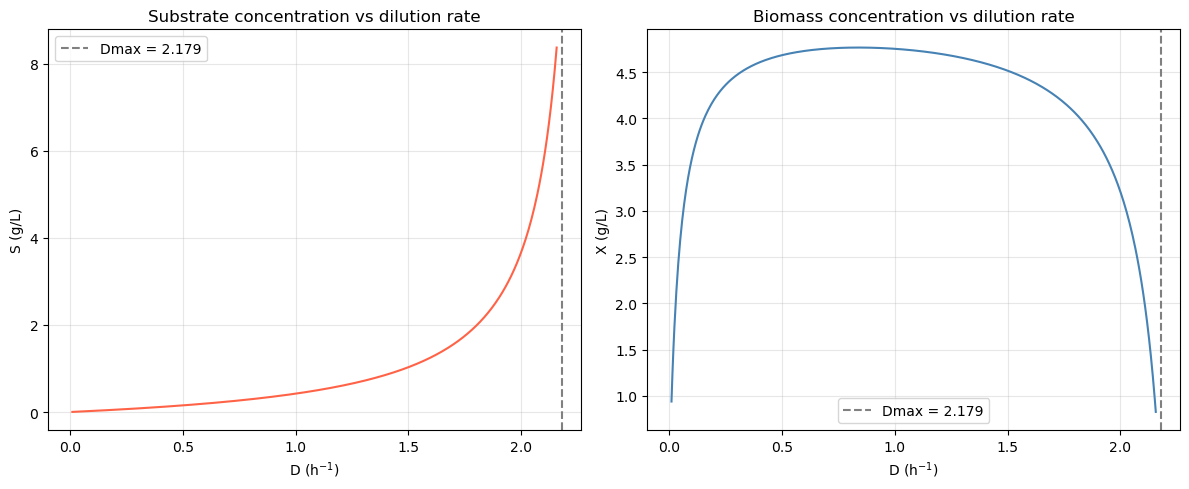

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


mu_max = 2.298
Ks = 0.548
Yxs = 0.5185
m = 0.0872 
S_in = 10.0

D_max = mu_max * S_in / (Ks + S_in)

D_range = np.linspace(0.01, 0.99 * D_max, 500)

S_model = (D_range * Ks) / (mu_max - D_range)

X_model = D_range * (S_in - S_model) / (D_range / Yxs + m)

X_model[X_model < 0] = np.nan
S_model[S_model < 0] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(D_range, S_model, color="tomato")
axes[0].axvline(D_max, color="grey", linestyle="--", label=f"Dmax = {D_max:.3f}")
axes[0].set_xlabel("D (h$^{-1}$)")
axes[0].set_ylabel("S (g/L)")
axes[0].set_title("Substrate concentration vs dilution rate")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(D_range, X_model, color="steelblue")
axes[1].axvline(D_max, color="grey", linestyle="--", label=f"Dmax = {D_max:.3f}")
axes[1].set_xlabel("D (h$^{-1}$)")
axes[1].set_ylabel("X (g/L)")
axes[1].set_title("Biomass concentration vs dilution rate")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The parameters estimated previously were used:

$$
\mu_{\max}=2.298\ \mathrm{h^{-1}}, \quad K_s=0.548\ \mathrm{g/L}
$$

$$
Y_{X/S}=0.5185\ \mathrm{g_X/g_S}, \quad m=0.0872\ \mathrm{g_S\,g_X^{-1}\,h^{-1}}
$$

with

$$
S_{in}=10\ \mathrm{g/L}
$$

The variation of substrate and biomass concentrations as a function of dilution rate follows the expected behavior of a chemostat system. In fact, the substrate concentration increases with the dilution rate, which is expected because at low dilution rates, the residence time is long, which allows microorganisms to efficiently consume the substrate, which results in low residual substrate concentrations. As the dilution rate increases, there is less time available for substrate consumption, reasulting in higher substrate concentrations. When we get close to the maximum dilution rate $D_{\max}$,the substrate concentration increases sharply and approaches the feed concentration, indicating that the cells are no longer able to consume the incoming substrate efficiently.

The biomass concentration shows a different looking trend. At low dilution rates, the biomass concentration is limited due to the effect of maintenance energy, which consumes a significant portion of the substrate for non-growth-related processes. As the dilution rate increases, biomass concentration rises because more substrate becomes available for growth. However, near $D_{\max}$, the biomass concentration decreases sharply due to washout, as cells are removed from the reactor faster than they can reproduce. 

Overall, the results illustrate the typical trade-off in chemostat operation: low dilution rates lead to efficient substrate utilization but lower productivity due to maintenance effects, while high dilution rates lead to washout. The optimal operating region lies between these two extremes.

**Question e)**

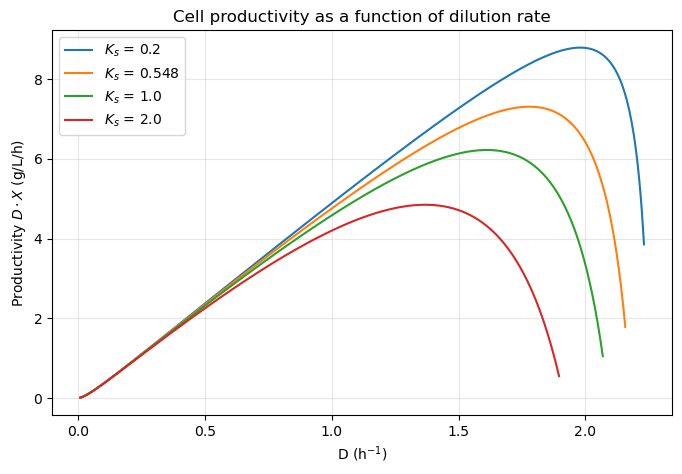

In [12]:
import numpy as np
import matplotlib.pyplot as plt

mu_max = 2.298
Ks = 0.548
Yxs = 0.5185
m = 0.0872
S_in = 10.0

D_max = mu_max * S_in / (Ks + S_in)
D_range = np.linspace(0.01, 0.99 * D_max, 500)

S_model = (D_range * Ks) / (mu_max - D_range)
X_model = D_range * (S_in - S_model) / (D_range / Yxs + m)
P_model = D_range * X_model

X_model[X_model < 0] = np.nan
P_model[P_model < 0] = np.nan

Ks_values = [0.2, 0.548, 1.0, 2.0]

plt.figure(figsize=(8,5))

for Ks_i in Ks_values:
    D_max_i = mu_max * S_in / (Ks_i + S_in)
    D_i = np.linspace(0.01, 0.99 * D_max_i, 500)
    S_i = (D_i * Ks_i) / (mu_max - D_i)
    X_i = D_i * (S_in - S_i) / (D_i / Yxs + m)
    P_i = D_i * X_i

    X_i[X_i < 0] = np.nan
    P_i[P_i < 0] = np.nan

    plt.plot(D_i, P_i, label=f"$K_s$ = {Ks_i}")

plt.xlabel("D (h$^{-1}$)")
plt.ylabel("Productivity $D \\cdot X$ (g/L/h)")
plt.title("Cell productivity as a function of dilution rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The cell productivity was calculated as

$$
P_X = D \cdot X
$$

where $X(D)$ was obtained from the steady-state chemostat model including maintenance energy:

$$
X(D)=\frac{D(S_{in}-S(D))}{\frac{D}{Y_{X/S}}+m}
$$

with

$$
S(D)=\frac{D K_s}{\mu_{\max}-D}
$$

The variation of cell productivity as a function of the dilution rate shows the typical behavior expected in a chemostat system. For all values of $K_s$, the productivity initially increases with the dilution rate. At low dilution rates, although the biomass concentration is relatively high, the flow rate is low, resulting in limited productivity. As $D$ increases, both the biomass output and the flow rate contribute to a rise in productivity. However, beyond a certain dilution rate, the productivity reaches a maximum and then decreases sharply. This is due to the reduction in biomass concentration as the system approaches washout. At high dilution rates, cells are removed from the reactor faster than they can reproduce, leading to a significant drop in biomass and, therefore, productivity.

The effect of the Monod constant $K_s$ is clearly illustrated in the results. Lower values of $K_s$ correspond to higher substrate affinity, allowing the microorganisms to grow efficiently even at low substrate concentrations. This results in higher biomass concentrations and higher maximum productivity.In contrast, increasing $K_s$ reduces the substrate affinity of the cells. As a result, higher substrate concentrations are required to sustain growth, leading to less efficient substrate utilization. This is reflected in the lower biomass concentrations and reduced maximum productivity observed for higher $K_s$ values. Additionally, we can see that the maximum productivity shifts to lower dilution rates as $K_s$ increases. This shows that for systems with poorer substrate affinity, optimal operation occurs at lower dilution rates to compensate for the reduced growth efficiency.

**Question f)**

Maximum productivity = 7.3058 g/L/h
Dilution rate at maximum productivity = 1.7782 h^-1


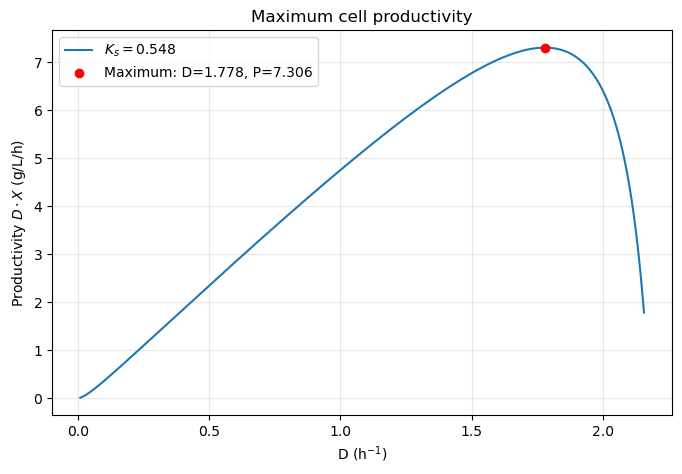

In [ ]:
import numpy as np

idx_max = np.nanargmax(P_model)

D_opt_num = D_range[idx_max]
P_max = P_model[idx_max]

print(f"Maximum productivity = {P_max:.4f} g/L/h")
print(f"Dilution rate at maximum productivity = {D_opt_num:.4f} h^-1")

plt.figure(figsize=(8,5))
plt.plot(D_range, P_model, label=r"$K_s = 0.548$")
plt.scatter(D_opt_num, P_max, color="red", zorder=5,
            label=f"Maximum: D={D_opt_num:.3f}, P={P_max:.3f}")

plt.xlabel("D (h$^{-1}$)")
plt.ylabel("Productivity $D \cdot X$ (g/L/h)")
plt.title("Maximum cell productivity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The maximum cell productivity was determined numerically from the productivity curve:

$$
P_X(D) = D \cdot X(D)
$$

The results obtained are:

$$
P_{X,\max} = 7.3058\ \mathrm{g\,L^{-1}\,h^{-1}}
$$

$$
D_{\mathrm{opt}} = 1.7782\ \mathrm{h^{-1}}
$$

This value of the dilution rate corresponds to the optimal operating condition for biomass production for our Ks value. The existence of an optimal dilution rate reflects the trade-off between biomass concentration and dilution rate. In fact, increasing $D$ increases the flow of biomass, but reduces the biomass concentration. The maximum productivity is reached at the balance between these two competing effects. Overall, the results are consistent with the expected behavior of a chemostat system and confirm that the optimal operating point lies below the maximum dilution rate.